In [1]:
import pandas as pd

In [2]:
path = '../data/processed/cleaned_data.csv'
dataset = pd.read_csv(path)

In [3]:
dataset.head(3)

,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.0,0.0,0.0,619,42,2,0.00,1,1,1,101348.88,1
1,0.0,1.0,0.0,608,41,1,83807.86,1,0,1,112542.58,0
2,0.0,0.0,0.0,502,42,8,159660.80,3,1,0,113931.57,1


In [4]:
x = dataset.drop('Exited', axis = 1)
y = dataset['Exited']

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2)

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = scaler.get_feature_names_out(), index = x_train.index)

In [10]:
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns = scaler.get_feature_names_out(), index = x_test.index)

In [11]:
import tensorflow

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [13]:
ann = Sequential()

In [14]:
ann.add(Input(shape = (11,)))

ann.add(Dense(32, activation = 'relu', kernel_regularizer = l2(l2=0.001)))
ann.add(BatchNormalization())
ann.add(Dropout(0.2))

ann.add(Dense(16, activation='relu', kernel_regularizer = l2(l2=0.001)))
ann.add(BatchNormalization())
ann.add(Dropout(0.2))

ann.add(Dense(8, activation='relu', kernel_regularizer = l2(l2=0.001)))

ann.add(Dense(1, activation='sigmoid'))

In [15]:
ann.compile( optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tensorflow.keras.metrics.Recall()])

In [16]:
ann.fit(x_train_scaled, y_train, callbacks = [EarlyStopping()], validation_data = (x_test_scaled, y_test), epochs = 50, batch_size = 32, class_weight={0:1, 1:2})

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7143 - loss: 0.8059 - recall: 0.3723 - val_accuracy: 0.7970 - val_loss: 0.5465 - val_recall: 0.3995
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7726 - loss: 0.7280 - recall: 0.4288 - val_accuracy: 0.8055 - val_loss: 0.5019 - val_recall: 0.5115
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7782 - loss: 0.6979 - recall: 0.4702 - val_accuracy: 0.8230 - val_loss: 0.4735 - val_recall: 0.5394
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7810 - loss: 0.6752 - recall: 0.5213 - val_accuracy: 0.8230 - val_loss: 0.4603 - val_recall: 0.5445
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7985 - loss: 0.6472 - recall: 0.5566 - val_accuracy: 0.8335 - val_loss: 0.4443 - val_recall: 0.6005
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8052 - loss: 0.6366 - recall: 0.5888 - val_accuracy: 0.8335 - val_loss: 0.4355 - val_recall: 0.6183
Epoc

In [17]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score, precision_score, accuracy_score

In [18]:
y_pred_test = ann.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [19]:
y_pred_train = ann.predict(x_train_scaled)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step


In [20]:
y_pred_2 = []
for i in y_pred_test:
    if i > 0.5:
        y_pred_2.append(1)
    else:
        y_pred_2.append(0)

In [21]:
y_pred_1 = []
for i in y_pred_train:
    if i > 0.5:
        y_pred_1.append(1)
    else:
        y_pred_1.append(0)

In [22]:
accuracy_score(y_train, y_pred_1) * 100, accuracy_score(y_test, y_pred_2) * 100

(84.3375, 84.2)

In [23]:
recall_score(y_test, y_pred_2) * 100

62.086513994910945

In [24]:
precision_score(y_test, y_pred_2) * 100

59.36739659367397

In [25]:
f1_score(y_test, y_pred_2) * 100

60.69651741293532

In [26]:
cm = confusion_matrix(y_test, y_pred_2)

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

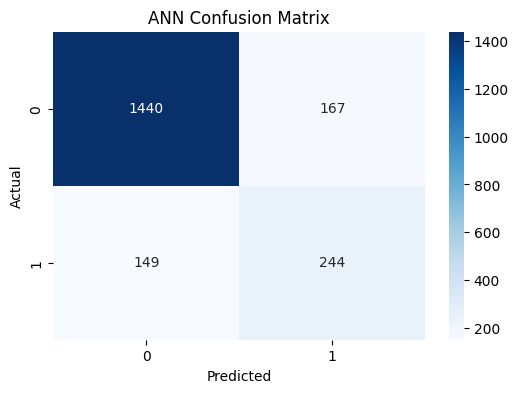

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap='Blues')
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/ann_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [29]:
ann.save("../models/ann_model.h5")

In [30]:
ann_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
    ],
    "Value": [
        accuracy_score(y_test, y_pred_2),
        precision_score(y_test, y_pred_2),
        recall_score(y_test, y_pred_2),
        f1_score(y_test, y_pred_2)
    ]
})

In [31]:
ann_metrics

,Metric,Value
0,Accuracy,0.842000
1,Precision,0.593674
2,Recall,0.620865
3,F1 Score,0.606965


In [32]:
ann_metrics.to_csv("../reports/ann_metrics.csv", index=False)